# Core 4-country portfolio client notebook

Portefeuille de reference gele : **France + Sweden + Netherlands + Germany mitigated**.

Ce notebook charge les series mensuelles figees, regenere les rendements journaliers des livres depuis le moteur, calcule les poids simples, puis trace l'equity curve daily, le drawdown et les diagnostics de diversification.


In [12]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

ROOT = Path.cwd()
if not (ROOT / 'config' / 'core_portfolio_reference.json').exists():
    ROOT = ROOT.parent
if not (ROOT / 'config' / 'core_portfolio_reference.json').exists():
    raise FileNotFoundError('Run this notebook from the repo root or from the notebook/ folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CONFIG_PATH = ROOT / 'config' / 'core_portfolio_reference.json'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    CONFIG = json.load(f)

print(f"Repo root: {ROOT}")
print(f"Portfolio: {CONFIG['portfolio_id']} | status={CONFIG['status']} | frozen_at={CONFIG['frozen_at']}")


Repo root: d:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal
Portfolio: core_4_country_v1 | status=frozen_reference | frozen_at=2026-04-21


## Parametres figes du portefeuille

In [13]:
books = pd.DataFrame(CONFIG['books'])
cols = ['book', 'country', 'role', 'config_name', 'logic', 'maturity_status', 'notes']
display(books[cols])

print('Periode:', CONFIG['period']['start'], '->', CONFIG['period']['end'])
print('Weighting par defaut:', CONFIG['default_weight_scheme'])
print('Methodologie:', CONFIG['methodology_note'])


,book,country,role,config_name,logic,maturity_status,notes
0,france,france,core_book,reference,France local reference baseline,top_pf_qualified,France enters as a simple local baseline book.
1,sweden,sweden,core_book,best_plus_regime_filter,Sweden local C regime filter,advanced_local_validated,Sweden uses the locally validated regime-filte...
2,netherlands,netherlands,supporting_book,reference,Netherlands local reference baseline,top_pf_qualified_supporting,Netherlands is retained as a simple diversifyi...
3,germany,germany,core_book,pair_filter_corr_abs_le_0p75_bypass_scan_stres...,Germany corr<=0.75 pair filter with scan-time ...,shadow_validation_promoted,Germany enters after shadow validation; 2025 s...


Periode: 2018-01-01 -> 2025-12-31
Weighting par defaut: inverse_vol
Methodologie: Frozen client reference built from fixed local country books. No cross-country universal trading rule, no Markowitz optimization, no retuning in this notebook.


## Chargement des rendements par livre


In [14]:
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.core_portfolio_daily import load_or_build_core_daily_returns, monthly_returns_from_daily


def normalize_month(value):
    dt = pd.to_datetime(value, errors='coerce')
    if isinstance(dt, pd.Series):
        return dt.dt.to_period('M').dt.to_timestamp()
    return dt.to_period('M').to_timestamp()


def load_book_monthly_returns(book_cfg: dict) -> pd.DataFrame:
    path = ROOT / book_cfg['source_dir'] / book_cfg['source_file']
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    if 'trade_month' not in df.columns or 'month_return' not in df.columns:
        raise ValueError(f'Missing trade_month/month_return in {path}')
    df = df.copy()
    df['trade_month'] = normalize_month(df['trade_month'])
    df['month_return'] = pd.to_numeric(df['month_return'], errors='coerce')
    if 'config_name' in df.columns:
        df = df[df['config_name'].astype(str).eq(str(book_cfg['source_config_name']))].copy()
    if 'book' in df.columns:
        df = df[df['book'].astype(str).eq(str(book_cfg['source_book']))].copy()
    df['book'] = book_cfg['book']
    df['country'] = book_cfg['country']
    df['config_name'] = book_cfg['config_name']
    df = df[['trade_month', 'book', 'country', 'config_name', 'month_return']]
    return df.dropna(subset=['trade_month', 'month_return']).sort_values('trade_month')


period_start = pd.Timestamp(CONFIG['period']['start']).normalize()
period_end = pd.Timestamp(CONFIG['period']['end']).normalize()
monthly_start = period_start.to_period('M').to_timestamp()
monthly_end = period_end.to_period('M').to_timestamp()

monthly = pd.concat([load_book_monthly_returns(b) for b in CONFIG['books']], ignore_index=True)
monthly = monthly[(monthly['trade_month'] >= monthly_start) & (monthly['trade_month'] <= monthly_end)].copy()
returns_monthly = monthly.pivot_table(index='trade_month', columns='book', values='month_return', aggfunc='sum').sort_index().fillna(0.0)

DAILY_CACHE_DIR = ROOT / 'data' / 'experiments' / 'core_portfolio_reference_daily_cache'
REBUILD_DAILY_CACHE = False

daily, returns_daily = load_or_build_core_daily_returns(
    CONFIG,
    root=ROOT,
    cache_dir=DAILY_CACHE_DIR,
    rebuild=REBUILD_DAILY_CACHE,
)

returns = returns_daily
PERIODS_PER_YEAR = 252
RETURN_FREQUENCY = 'daily'

monthly_from_daily = monthly_returns_from_daily(returns_daily)
common_books = returns_monthly.columns.intersection(monthly_from_daily.columns)
monthly_check = (
    (monthly_from_daily[common_books] - returns_monthly[common_books])
    .abs()
    .max()
    .rename('max_abs_diff_daily_vs_frozen_monthly')
    .reset_index()
    .rename(columns={'index': 'book'})
)

print(f'Months source: {len(returns_monthly)} | start={returns_monthly.index.min().date()} | end={returns_monthly.index.max().date()}')
print(f'Daily observations: {len(returns)} | start={returns.index.min().date()} | end={returns.index.max().date()}')
print(f'Daily cache: {DAILY_CACHE_DIR}')
display(returns.tail())
display(Markdown('### Controle monthly: daily regenere vs source figee'))
display(monthly_check)


Months source: 96 | start=2018-01-01 | end=2025-12-01
Daily observations: 2088 | start=2018-01-01 | end=2025-12-31
Daily cache: d:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\data\experiments\core_portfolio_reference_daily_cache


book,france,germany,netherlands,sweden
trade_date,,,,
2025-12-25,0.0,0.0,0.0,0.0
2025-12-26,0.0,0.0,0.0,0.0
2025-12-29,0.0,0.0,0.0,0.0
2025-12-30,0.0,0.0,0.0,0.0
2025-12-31,0.0,0.0,0.0,0.0


### Controle monthly: daily regenere vs source figee

,book,max_abs_diff_daily_vs_frozen_monthly
0,france,1.415534e-15
1,germany,1.332268e-15
2,netherlands,1.412065e-15
3,sweden,1.413800e-15


## Fonctions de metrics et de pond?ration

In [15]:
def drawdown_from_equity(equity: pd.Series):
    eq = pd.to_numeric(equity, errors='coerce').dropna()
    if eq.empty:
        return np.nan, pd.NaT, pd.NaT, pd.Series(dtype=float)
    peak = eq.cummax()
    dd = eq / peak - 1.0
    trough = dd.idxmin()
    peak_date = eq.loc[:trough].idxmax() if len(eq) else pd.NaT
    return float(dd.loc[trough]), peak_date, trough, dd


def max_drawdown(series: pd.Series):
    r = pd.to_numeric(series, errors='coerce').fillna(0.0)
    if r.empty:
        return np.nan, pd.NaT, pd.NaT, pd.Series(dtype=float), pd.Series(dtype=float)
    equity = (1.0 + r).cumprod()
    dd, peak_date, trough, drawdown = drawdown_from_equity(equity)
    return dd, peak_date, trough, equity, drawdown


def additive_equity(series: pd.Series) -> pd.Series:
    r = pd.to_numeric(series, errors='coerce').fillna(0.0)
    return 1.0 + r.cumsum()


def return_metrics(series: pd.Series, periods_per_year: int = 252) -> dict:
    r = pd.to_numeric(series, errors='coerce').dropna()
    if r.empty:
        return {}
    total_return = float((1.0 + r).prod() - 1.0)
    ann_return = float((1.0 + total_return) ** (periods_per_year / len(r)) - 1.0) if total_return > -1 else -1.0
    vol = r.std(ddof=1)
    ann_vol = float(vol * np.sqrt(periods_per_year)) if len(r) > 1 else np.nan
    sharpe = float((r.mean() / vol) * np.sqrt(periods_per_year)) if len(r) > 1 and vol > 0 else np.nan
    dd, dd_start, dd_end, _eq, _drawdown = max_drawdown(r)
    return {
        'n_obs': int(len(r)),
        'periods_per_year': int(periods_per_year),
        'total_return': total_return,
        'annualized_return': ann_return,
        'annualized_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': dd,
        'dd_start': dd_start,
        'dd_end': dd_end,
        'positive_rate': float((r > 0).mean()),
        'worst_return': float(r.min()),
        'best_return': float(r.max()),
    }


def additive_metrics(series: pd.Series, periods_per_year: int = 252) -> dict:
    r = pd.to_numeric(series, errors='coerce').dropna()
    if r.empty:
        return {}
    eq = additive_equity(r)
    total_return = float(eq.iloc[-1] - 1.0)
    ann_return = float(r.mean() * periods_per_year)
    vol = r.std(ddof=1)
    ann_vol = float(vol * np.sqrt(periods_per_year)) if len(r) > 1 else np.nan
    sharpe = float((r.mean() / vol) * np.sqrt(periods_per_year)) if len(r) > 1 and vol > 0 else np.nan
    dd, dd_start, dd_end, _drawdown = drawdown_from_equity(eq)
    return {
        'n_obs': int(len(r)),
        'periods_per_year': int(periods_per_year),
        'total_return': total_return,
        'annualized_return': ann_return,
        'annualized_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': dd,
        'dd_start': dd_start,
        'dd_end': dd_end,
        'positive_rate': float((r > 0).mean()),
        'worst_return': float(r.min()),
        'best_return': float(r.max()),
    }


def compute_weights(returns: pd.DataFrame, scheme: str) -> pd.Series:
    if scheme == 'equal_weight':
        return pd.Series(1.0 / returns.shape[1], index=returns.columns)
    if scheme == 'inverse_vol':
        vol = returns.std(ddof=1).replace(0, np.nan)
        inv = 1.0 / vol
        if inv.isna().any() or inv.sum() <= 0:
            raise ValueError('Cannot compute inverse_vol weights from current return matrix.')
        return inv / inv.sum()
    raise ValueError(f'Unknown weight scheme: {scheme}')


def portfolio_returns(returns: pd.DataFrame, weights: pd.Series) -> pd.Series:
    weights = weights.reindex(returns.columns).fillna(0.0)
    return returns.mul(weights, axis=1).sum(axis=1)


## Synthese par livre

In [16]:
book_summary = []
for book in returns.columns:
    m = return_metrics(returns[book], periods_per_year=PERIODS_PER_YEAR)
    book_summary.append({'book': book, **m})
book_summary = pd.DataFrame(book_summary).sort_values('sharpe', ascending=False)
display(book_summary[['book', 'n_obs', 'total_return', 'annualized_return', 'annualized_vol', 'sharpe', 'max_drawdown', 'positive_rate', 'worst_return', 'best_return']])


,book,n_obs,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,positive_rate,worst_return,best_return
1,germany,2088,3.736910,0.206494,0.243695,0.893070,-0.281677,0.319444,-0.177606,0.111941
3,sweden,2088,2.005651,0.142042,0.185487,0.808252,-0.362058,0.388410,-0.078952,0.115454
0,france,2088,2.984500,0.181569,0.284774,0.727924,-0.335364,0.406130,-0.155818,0.148569
2,netherlands,2088,0.832446,0.075834,0.168671,0.517318,-0.350989,0.261973,-0.081889,0.077676


## Construction du portefeuille

In [17]:
WEIGHT_SCHEME = CONFIG['default_weight_scheme']  # 'inverse_vol' ou 'equal_weight'
WEIGHT_ESTIMATION_FREQUENCY = 'monthly_reference'
weight_input = returns_monthly if WEIGHT_ESTIMATION_FREQUENCY == 'monthly_reference' else returns

weights = compute_weights(weight_input, WEIGHT_SCHEME)
port_ret = portfolio_returns(returns, weights)
metrics = return_metrics(port_ret, periods_per_year=PERIODS_PER_YEAR)
metrics_additive = additive_metrics(port_ret, periods_per_year=PERIODS_PER_YEAR)
dd, dd_start, dd_end, equity, drawdown = max_drawdown(port_ret)
equity_additive = additive_equity(port_ret)
dd_additive, dd_start_additive, dd_end_additive, drawdown_additive = drawdown_from_equity(equity_additive)

weights_frame = weights.rename('weight').reset_index().rename(columns={'index': 'book'})
display(Markdown(f"### Poids utilises: `{WEIGHT_SCHEME}` | estimation: `{WEIGHT_ESTIMATION_FREQUENCY}`"))
display(weights_frame)

metrics_compare = pd.DataFrame([
    {'equity_mode': 'compounded_reinvested', **metrics},
    {'equity_mode': 'additive_fixed_notional', **metrics_additive},
]).set_index('equity_mode')

display(Markdown('### Metrics portefeuille daily'))
display(metrics_compare.T)


### Poids utilises: `inverse_vol` | estimation: `monthly_reference`

,book,weight
0,france,0.175369
1,germany,0.217478
2,netherlands,0.349641
3,sweden,0.257512


### Metrics portefeuille daily

equity_mode,compounded_reinvested,additive_fixed_notional
n_obs,2088,2088
periods_per_year,252,252
total_return,2.361668,1.266046
annualized_return,0.157577,0.152799
annualized_vol,0.113651,0.113651
sharpe,1.344453,1.344453
max_drawdown,-0.10421,-0.071036
dd_start,2020-02-26 00:00:00,2020-02-26 00:00:00
dd_end,2020-03-23 00:00:00,2020-03-23 00:00:00
positive_rate,0.502395,0.502395


## Equity curve et drawdown

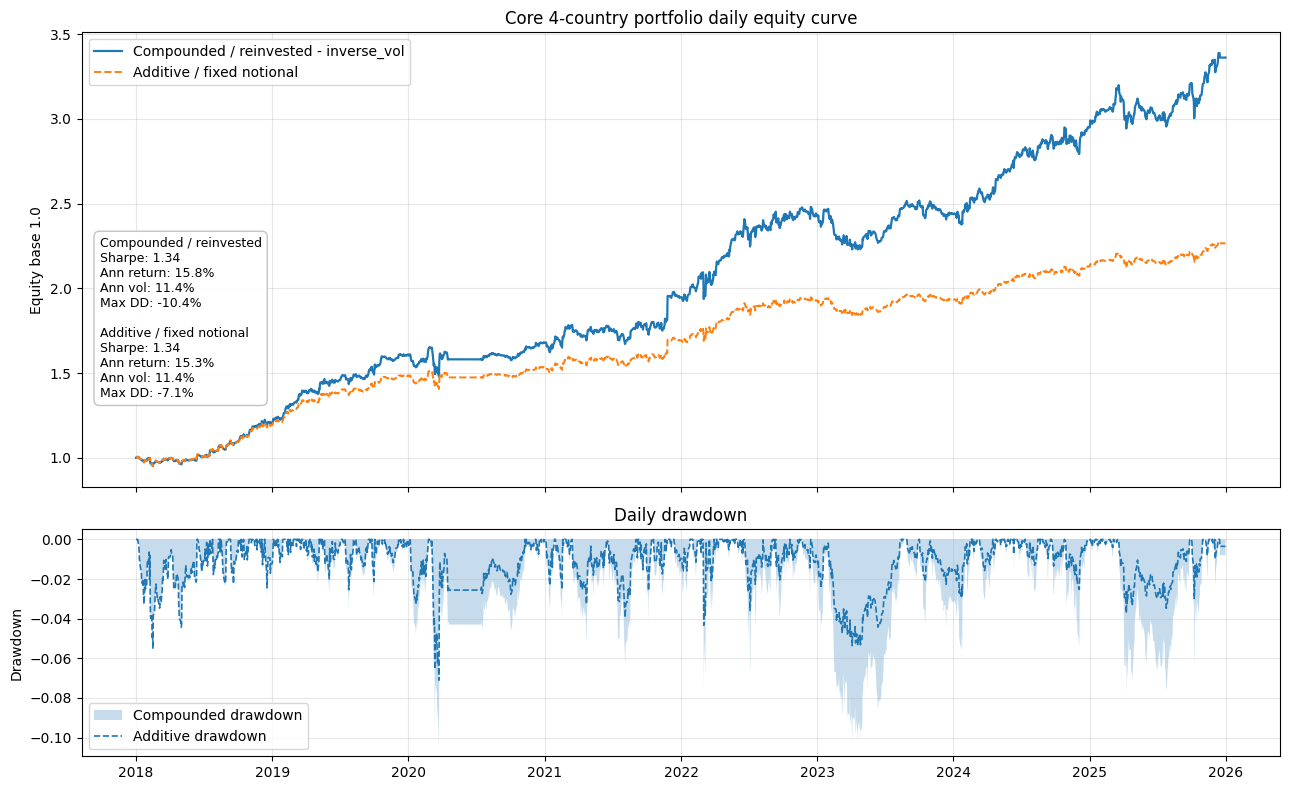

In [18]:
def format_metric_line(label: str, row: pd.Series) -> str:
    return (
        f"{label}\n"
        f"Sharpe: {row['sharpe']:.2f}\n"
        f"Ann return: {row['annualized_return']:.1%}\n"
        f"Ann vol: {row['annualized_vol']:.1%}\n"
        f"Max DD: {row['max_drawdown']:.1%}"
    )

metric_text = "\n\n".join([
    format_metric_line('Compounded / reinvested', metrics_compare.loc['compounded_reinvested']),
    format_metric_line('Additive / fixed notional', metrics_compare.loc['additive_fixed_notional']),
])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(equity.index, equity.values, linewidth=1.6, label=f'Compounded / reinvested - {WEIGHT_SCHEME}')
axes[0].plot(equity_additive.index, equity_additive.values, linewidth=1.4, linestyle='--', label='Additive / fixed notional')
axes[0].set_title('Core 4-country portfolio daily equity curve')
axes[0].set_ylabel('Equity base 1.0')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left')
axes[0].text(
    0.015,
    0.55,
    metric_text,
    transform=axes[0].transAxes,
    va='top',
    ha='left',
    fontsize=9,
    bbox={'boxstyle': 'round,pad=0.45', 'facecolor': 'white', 'edgecolor': '#bbbbbb', 'alpha': 0.88},
)

axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.25, label='Compounded drawdown')
axes[1].plot(drawdown_additive.index, drawdown_additive.values, linewidth=1.2, linestyle='--', label='Additive drawdown')
axes[1].set_title('Daily drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


## Comparatif des allocateurs walk-forward

Allocation research run: d:\Business\Trading\VSCODE\algo-trading-stat-arb-terminal\data\experiments\portfolio_allocation_research_france_germany_netherlands_sweden_20260423_000056_codex_main_final


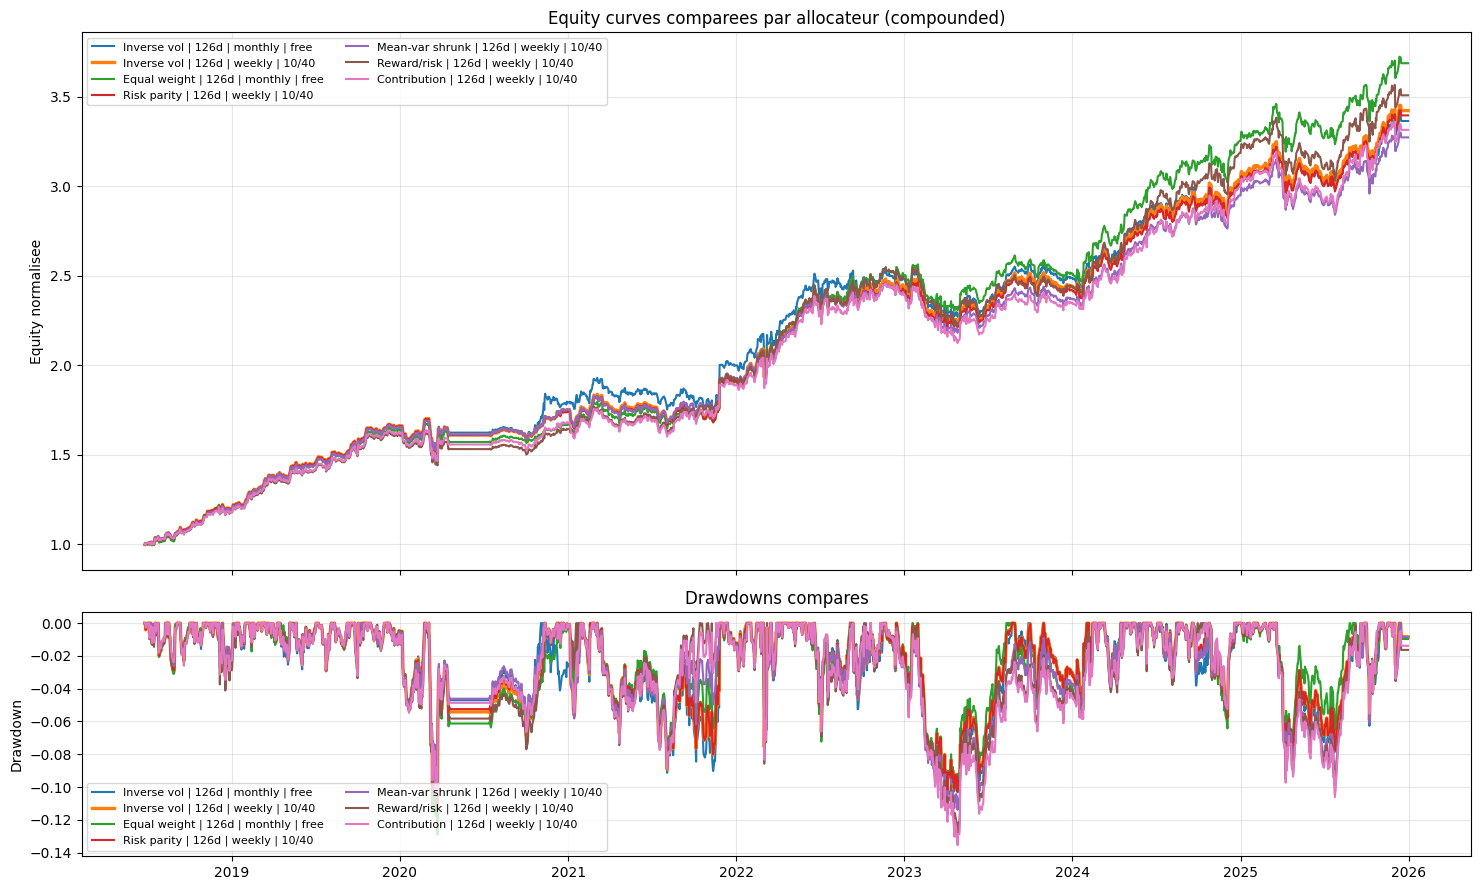

,label,ann_return,ann_vol,sharpe,sortino,max_drawdown,calmar,avg_rebalance_turnover,avg_effective_n_books,avg_max_book_weight
config_id,,,,,,,,,,
equal_weight__lb126__monthly__unconstrained,Equal weight | 126d | monthly | free,18.30%,12.43%,1.41,2.00,-12.91%,1.42,0.00%,4.00,25.00%
inverse_vol__lb126__weekly__floor_cap,Inverse vol | 126d | weekly | 10/40,17.08%,11.98%,1.38,1.98,-11.52%,1.48,1.28%,3.86,28.68%
risk_parity__lb126__weekly__floor_cap,Risk parity | 126d | weekly | 10/40,16.97%,11.95%,1.37,1.98,-11.34%,1.50,1.33%,3.85,28.69%
mean_variance_shrunk__lb126__weekly__floor_cap,Mean-var shrunk | 126d | weekly | 10/40,16.40%,11.75%,1.35,1.91,-11.38%,1.44,3.12%,3.77,29.00%
reward_to_risk__lb126__weekly__floor_cap,Reward/risk | 126d | weekly | 10/40,17.44%,12.52%,1.35,1.85,-12.96%,1.35,3.20%,3.73,25.53%
inverse_vol__lb126__monthly__unconstrained,Inverse vol | 126d | monthly | free,16.91%,12.33%,1.33,1.94,-11.88%,1.42,6.84%,3.61,30.58%
contribution_based__lb126__weekly__floor_cap,Contribution | 126d | weekly | 10/40,16.59%,12.26%,1.31,1.82,-13.54%,1.23,3.20%,3.73,26.26%


In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    ROOT
except NameError:
    cwd = Path.cwd()
    ROOT = cwd.parent if cwd.name == 'notebook' else cwd

try:
    display
except NameError:
    from IPython.display import display

ALLOC_COMPOUNDING_MODE = 'compounded'
ALLOCATION_RESEARCH_DIR_OVERRIDE = globals().get('ALLOCATION_RESEARCH_DIR_OVERRIDE', None)

if ALLOCATION_RESEARCH_DIR_OVERRIDE is None:
    experiments_dir = ROOT / 'data' / 'experiments'
    allocation_runs = sorted(
        [
            p for p in experiments_dir.glob('portfolio_allocation_research_*')
            if (p / 'portfolio_equity_curves.csv').exists()
            and (p / 'allocation_ranking.csv').exists()
            and (p / 'allocation_run_level.csv').exists()
        ],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not allocation_runs:
        raise FileNotFoundError('Aucun run portfolio_allocation_research_* trouve dans data/experiments.')
    ALLOCATION_RESEARCH_DIR = allocation_runs[0]
else:
    ALLOCATION_RESEARCH_DIR = Path(ALLOCATION_RESEARCH_DIR_OVERRIDE)

print(f'Allocation research run: {ALLOCATION_RESEARCH_DIR}')

alloc_equity = pd.read_csv(ALLOCATION_RESEARCH_DIR / 'portfolio_equity_curves.csv', parse_dates=['date'])
alloc_ranking = pd.read_csv(ALLOCATION_RESEARCH_DIR / 'allocation_ranking.csv')
alloc_runs = pd.read_csv(ALLOCATION_RESEARCH_DIR / 'allocation_run_level.csv')

preferred_configs = [
    'inverse_vol__lb126__monthly__unconstrained',
    'inverse_vol__lb126__weekly__floor_cap',
    'equal_weight__lb126__monthly__unconstrained',
    'risk_parity__lb126__weekly__floor_cap',
    'mean_variance_shrunk__lb126__weekly__floor_cap',
    'reward_to_risk__lb126__weekly__floor_cap',
    'contribution_based__lb126__weekly__floor_cap',
]

available_configs = set(alloc_equity['config_id'].unique())
selected_configs = [config for config in preferred_configs if config in available_configs]

rank_mode = alloc_ranking[alloc_ranking['compounding_mode'].eq(ALLOC_COMPOUNDING_MODE)].copy()
sort_cols = [col for col in ['robust_rank_score', 'rank_sharpe', 'rank_calmar'] if col in rank_mode.columns]
if sort_cols:
    rank_mode = rank_mode.sort_values(sort_cols)

selected_methods = set(
    alloc_runs.loc[alloc_runs['config_id'].isin(selected_configs), 'method'].dropna().unique()
)
for row in rank_mode.drop_duplicates('method').itertuples():
    if row.method not in selected_methods and row.config_id in available_configs:
        selected_configs.append(row.config_id)
        selected_methods.add(row.method)

selected_configs = selected_configs[:8]
if not selected_configs:
    raise ValueError(f'Aucune configuration disponible pour {ALLOC_COMPOUNDING_MODE}.')

run_info = (
    alloc_runs[alloc_runs['compounding_mode'].eq(ALLOC_COMPOUNDING_MODE)]
    .drop_duplicates('config_id')
    .set_index('config_id')
)

method_labels = {
    'inverse_vol': 'Inverse vol',
    'equal_weight': 'Equal weight',
    'risk_parity': 'Risk parity',
    'mean_variance_shrunk': 'Mean-var shrunk',
    'reward_to_risk': 'Reward/risk',
    'contribution_based': 'Contribution',
}

def allocation_label(config_id):
    if config_id not in run_info.index:
        return config_id
    row = run_info.loc[config_id]
    method = method_labels.get(row['method'], row['method'])
    constraint = '10/40' if row['constraint_label'] == 'floor_cap' else 'free'
    return f"{method} | {int(row['lookback_days'])}d | {row['rebalance_frequency']} | {constraint}"

plot_data = alloc_equity[
    alloc_equity['compounding_mode'].eq(ALLOC_COMPOUNDING_MODE)
    & alloc_equity['config_id'].isin(selected_configs)
].copy()

equity_compare = plot_data.pivot(index='date', columns='config_id', values='equity').sort_index()
drawdown_compare = plot_data.pivot(index='date', columns='config_id', values='drawdown').sort_index()
first_values = equity_compare.apply(lambda col: col.dropna().iloc[0] if col.notna().any() else np.nan)
equity_compare = equity_compare.divide(first_values, axis=1)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})
for config_id in selected_configs:
    if config_id not in equity_compare.columns:
        continue
    label = allocation_label(config_id)
    linewidth = 2.4 if config_id.startswith('inverse_vol__lb126__weekly__floor_cap') else 1.5
    axes[0].plot(equity_compare.index, equity_compare[config_id], label=label, linewidth=linewidth)
    axes[1].plot(drawdown_compare.index, drawdown_compare[config_id], label=label, linewidth=linewidth)

axes[0].set_title(f'Equity curves comparees par allocateur ({ALLOC_COMPOUNDING_MODE})')
axes[0].set_ylabel('Equity normalisee')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

axes[1].set_title('Drawdowns compares')
axes[1].set_ylabel('Drawdown')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

metrics_cols = [
    'ann_return', 'ann_vol', 'sharpe', 'sortino', 'max_drawdown', 'calmar',
    'avg_rebalance_turnover', 'avg_effective_n_books', 'avg_max_book_weight',
]
metrics_compare_alloc = run_info.loc[[c for c in selected_configs if c in run_info.index], metrics_cols].copy()
metrics_compare_alloc.insert(0, 'label', [allocation_label(c) for c in metrics_compare_alloc.index])
metrics_compare_alloc = metrics_compare_alloc.sort_values('sharpe', ascending=False)

display(
    metrics_compare_alloc.style.format({
        'ann_return': '{:.2%}',
        'ann_vol': '{:.2%}',
        'sharpe': '{:.2f}',
        'sortino': '{:.2f}',
        'max_drawdown': '{:.2%}',
        'calmar': '{:.2f}',
        'avg_rebalance_turnover': '{:.2%}',
        'avg_effective_n_books': '{:.2f}',
        'avg_max_book_weight': '{:.2%}',
    })
)


## Contributions et diversification

,book,weight,weighted_compounded_return,sum_weighted_daily_returns
1,germany,0.217478,0.463011,0.392172
3,sweden,0.257512,0.364010,0.319879
0,france,0.175369,0.337594,0.301211
2,netherlands,0.349641,0.269211,0.252784


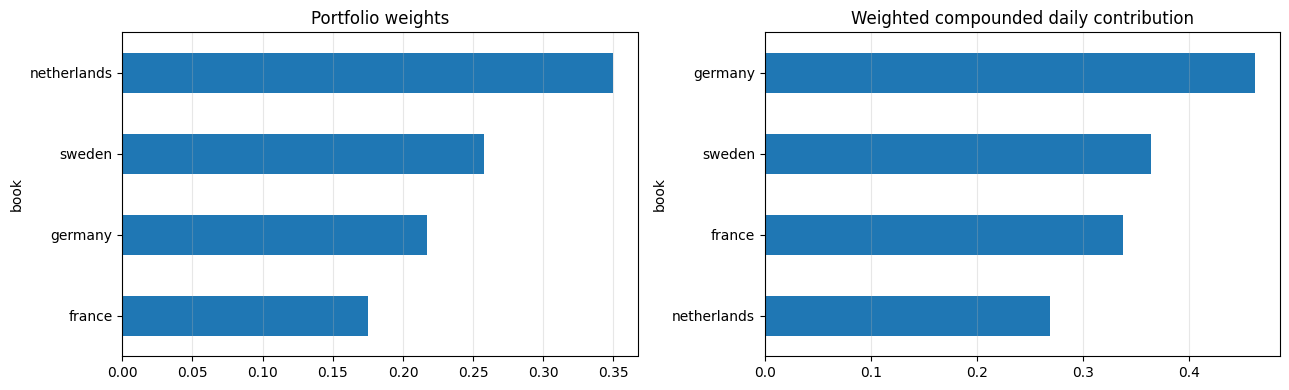

In [20]:
weighted_returns = returns.mul(weights, axis=1)
contrib_total = ((1.0 + weighted_returns).prod() - 1.0).rename('weighted_compounded_return')
contrib_simple = weighted_returns.sum().rename('sum_weighted_daily_returns')
contrib = pd.concat([weights.rename('weight'), contrib_total, contrib_simple], axis=1).reset_index().rename(columns={'index': 'book'})
display(contrib.sort_values('weighted_compounded_return', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
weights.sort_values().plot(kind='barh', ax=axes[0], title='Portfolio weights')
contrib_total.sort_values().plot(kind='barh', ax=axes[1], title='Weighted compounded daily contribution')
for ax in axes:
    ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Correlation entre livres

book,france,germany,netherlands,sweden
book,,,,
france,1.000000,0.120580,0.056553,0.098557
germany,0.120580,1.000000,0.019333,0.042377
netherlands,0.056553,0.019333,1.000000,0.013712
sweden,0.098557,0.042377,0.013712,1.000000


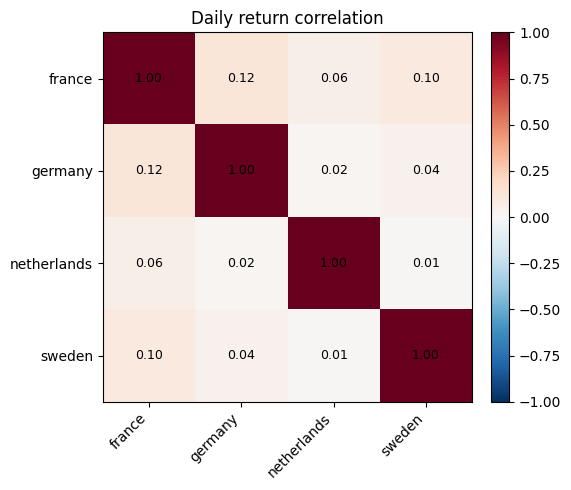

In [21]:
corr = returns.corr()
display(corr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Daily return correlation')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Fenetres recentes de controle

In [22]:
windows = {
    '2023_2025': ('2023-01-01', '2025-12-31'),
    '2024_2025': ('2024-01-01', '2025-12-31'),
    '2025': ('2025-01-01', '2025-12-31'),
}
rows = []
for name, (s, e) in windows.items():
    mask = (returns.index >= pd.Timestamp(s)) & (returns.index <= pd.Timestamp(e))
    r = returns.loc[mask]
    if r.empty:
        continue
    w = compute_weights(returns_monthly.loc[(returns_monthly.index >= pd.Timestamp(s)) & (returns_monthly.index <= pd.Timestamp(e))], WEIGHT_SCHEME)
    pr = portfolio_returns(r, w)
    rows.append({'window': name, 'start': s, 'end': e, **return_metrics(pr, periods_per_year=PERIODS_PER_YEAR)})
recent_summary = pd.DataFrame(rows)
display(recent_summary[['window', 'n_obs', 'total_return', 'annualized_return', 'annualized_vol', 'sharpe', 'max_drawdown', 'positive_rate', 'worst_return']])


,window,n_obs,total_return,annualized_return,annualized_vol,sharpe,max_drawdown,positive_rate,worst_return
0,2023_2025,783,0.389876,0.111771,0.099876,1.110971,-0.095699,0.508301,-0.031020
1,2024_2025,523,0.376304,0.166373,0.103526,1.538707,-0.080892,0.518164,-0.031395
2,2025,261,0.136107,0.131119,0.105537,1.220383,-0.079216,0.521073,-0.030641


## Export optionnel des series client

In [23]:
EXPORT_CLIENT_SERIES = False
if EXPORT_CLIENT_SERIES:
    out_dir = ROOT / 'data' / 'experiments' / 'core_portfolio_reference_client_exports'
    out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({'trade_date': port_ret.index, 'portfolio_daily_return': port_ret.values}).to_csv(out_dir / 'portfolio_daily_returns.csv', index=False)
    returns.to_csv(out_dir / 'book_daily_returns_wide.csv')
    returns_monthly.to_csv(out_dir / 'book_monthly_returns_wide.csv')
    weights_frame.to_csv(out_dir / 'portfolio_weights.csv', index=False)
    print('Exported to', out_dir)
else:
    print('EXPORT_CLIENT_SERIES=False. Passe a True pour ecrire les exports client.')


EXPORT_CLIENT_SERIES=False. Passe a True pour ecrire les exports client.


## Notes de lecture

- Le portefeuille est une **reference gelee** : le notebook ne retune aucun pays et ne cherche aucun nouveau poids optimise.
- Le schema par defaut est `inverse_vol`; `equal_weight` reste disponible en changeant `WEIGHT_SCHEME`.
- Germany utilise la version promue apres shadow validation : `pair_filter_corr_abs_le_0p75_bypass_scan_stress_trending`.
- Le point de vigilance principal reste Germany 2025 standalone, a surveiller au niveau livre mais non bloquant au niveau portefeuille core.
